# Titanic EDA Notebook

EDA means Exploratory Data Analysis. The goal is to understand the data before training a model.

Use this notebook by running each cell from top to bottom.

## 1. Import libraries

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

## 2. Load the dataset

In [2]:
DATA_PATH = Path("../01_titanic_survival/data/titanic_tiny.csv")
data = pd.read_csv(DATA_PATH)

data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22,1,0,7.2500,S
1,1,1,female,38,1,0,71.2833,C
2,1,3,female,26,0,0,7.9250,S
3,1,1,female,35,1,0,53.1000,S
4,0,3,male,35,0,0,8.0500,S


## 3. Basic shape

In [3]:
data.shape

(30, 8)

## 4. Column types and missing values

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  30 non-null     int64  
 1   pclass    30 non-null     int64  
 2   sex       30 non-null     str    
 3   age       30 non-null     int64  
 4   sibsp     30 non-null     int64  
 5   parch     30 non-null     int64  
 6   fare      30 non-null     float64
 7   embarked  30 non-null     str    
dtypes: float64(1), int64(5), str(2)
memory usage: 2.0 KB


In [5]:
data.isna().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

## 5. Numeric summary

In [6]:
data.describe()

,survived,pclass,age,sibsp,parch,fare
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.500000,2.366667,29.500000,0.566667,0.600000,24.591110
std,0.508548,0.850287,16.431152,0.935261,1.328728,20.067791
min,0.000000,1.000000,2.000000,0.000000,0.000000,7.225000
25%,0.000000,2.000000,19.250000,0.000000,0.000000,8.050000
50%,0.500000,3.000000,28.500000,0.000000,0.000000,17.350000
75%,1.000000,3.000000,38.000000,1.000000,0.750000,30.973950
max,1.000000,3.000000,65.000000,4.000000,5.000000,76.729200


## 6. Target balance

The target is `survived`. Check how many examples are 0 and 1.

In [7]:
data["survived"].value_counts()

survived
0    15
1    15
Name: count, dtype: int64

In [8]:
data["survived"].value_counts(normalize=True)

survived
0    0.5
1    0.5
Name: proportion, dtype: float64

## 7. Survival rate by sex

In [9]:
data.groupby("sex")["survived"].mean()

sex
female    0.857143
male      0.187500
Name: survived, dtype: float64

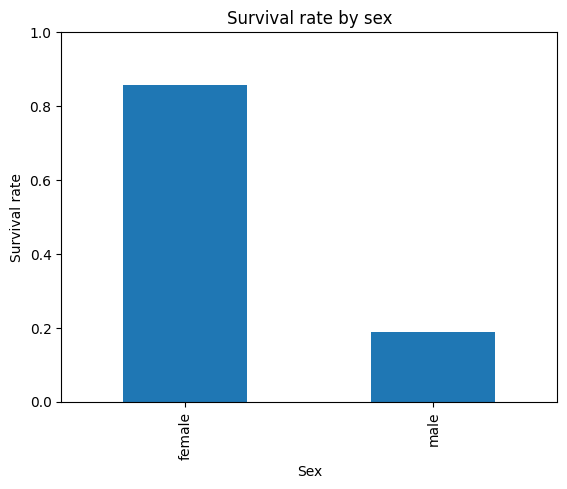

In [10]:
data.groupby("sex")["survived"].mean().plot(kind="bar")
plt.title("Survival rate by sex")
plt.ylabel("Survival rate")
plt.xlabel("Sex")
plt.ylim(0, 1)
plt.show()

## 8. Survival rate by passenger class

In [11]:
data.groupby("pclass")["survived"].mean()

pclass
1    0.714286
2    0.800000
3    0.333333
Name: survived, dtype: float64

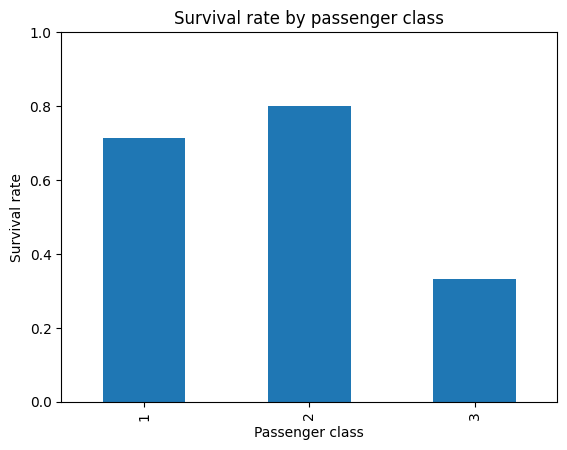

In [12]:
data.groupby("pclass")["survived"].mean().plot(kind="bar")
plt.title("Survival rate by passenger class")
plt.ylabel("Survival rate")
plt.xlabel("Passenger class")
plt.ylim(0, 1)
plt.show()

## 9. Create a feature

EDA often gives you ideas for new features. Here we create a simple `family_size` feature.

In [13]:
data["family_size"] = data["sibsp"] + data["parch"] + 1

data[["sibsp", "parch", "family_size"]].head()

,sibsp,parch,family_size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [14]:
data.groupby("family_size")["survived"].mean()

family_size
1    0.466667
2    0.500000
3    1.000000
5    0.000000
6    0.000000
7    0.500000
Name: survived, dtype: float64

## 10. Notes

Write what you noticed here:

- Which features seem useful?
- Are any columns missing values?
- Is the target balanced?
- What feature would you add to the training script?